# Titanic Survival Classification

## 1. Introduction

This project predicts whether a passenger survived the Titanic disaster using machine learning classification models.

We follow the complete Data Science workflow:

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing (with Pipeline - no leakage)
7. Train/Test Split
8. Model Training
9. Model Evaluation
10. Model Comparison
11. Feature Importance
12. Final Model Selection
13. Conclusion

**Dataset:** Titanic dataset from Kaggle (891 passengers with 12 features)
**Target variable:** `Survived` (0 = Did not survive, 1 = Survived)

## 2. Problem Statement

**Objective:** Build a machine learning model to predict whether a Titanic passenger survived based on features like age, gender, ticket class, fare, and other passenger information.

**Why this matters:** Understanding survival patterns helps us learn about feature importance, data preprocessing, and classification modeling — fundamental skills in data science.

**Approach:** We will clean the data, engineer meaningful features, train multiple classification models, and compare their performance to select the best one.

## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)

import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## 4. Load Dataset

We look for the Titanic dataset files in the `data/` directory. If `train.csv` or `test.csv` exist, we use them. Otherwise, we load the combined Titanic dataset.

In [2]:
data_path = '../data/'
notebook_path = os.getcwd()

if os.path.exists(os.path.join(notebook_path, 'data')):
    data_path = os.path.join(notebook_path, 'data')
elif os.path.exists(os.path.join(notebook_path, '..', 'data')):
    data_path = os.path.join(notebook_path, '..', 'data')
elif os.path.exists('data'):
    data_path = 'data'

print(f"Data directory: {os.path.abspath(data_path)}")

if os.path.exists(os.path.join(data_path, 'train.csv')):
    df = pd.read_csv(os.path.join(data_path, 'train.csv'))
    print("Loaded train.csv")
elif os.path.exists(os.path.join(data_path, 'titanic.csv')):
    df = pd.read_csv(os.path.join(data_path, 'titanic.csv'))
    print("Loaded titanic.csv")
else:
    for fname in ['train.csv', 'titanic.csv', '../data/train.csv', '../data/titanic.csv']:
        if os.path.exists(fname):
            df = pd.read_csv(fname)
            print(f"Loaded {fname}")
            break
    else:
        raise FileNotFoundError("No Titanic dataset found!")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Data directory: D:\Arch Tech Task1\data
Loaded titanic.csv
Dataset shape: (891, 12)
Rows: 891, Columns: 12


## 5. Data Understanding

Before any processing, we must understand the data:

- Number of rows and columns
- Data types of each feature
- Missing values
- Duplicate rows
- Basic statistics

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Number of passengers: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

DATASET OVERVIEW
Shape: (891, 12)
Number of passengers: 891
Number of features: 12


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print("Missing Values:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {missing.sum()}")

Missing Values:
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22

Total missing values: 866


In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [9]:
print("Unique Values in Categorical Features:")
print("=" * 60)
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f"\n{col}: {df[col].unique()}")
    print(f"  Value counts: {df[col].value_counts().to_dict()}")

Unique Values in Categorical Features:

Survived: [0 1]
  Value counts: {0: 549, 1: 342}

Pclass: [3 1 2]
  Value counts: {3: 491, 1: 216, 2: 184}

Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
  Value counts: {'male': 577, 'female': 314}

Embarked: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
  Value counts: {'S': 644, 'C': 168, 'Q': 77}


### Data Understanding Summary

- **891 passengers**, **12 features**
- **Target variable:** `Survived` (0/1)
- **Numerical features:** Age, SibSp, Parch, Fare, PassengerId
- **Categorical features:** Pclass, Sex, Ticket, Cabin, Embarked, Name
- **Missing values:** Age (177), Cabin (687), Embarked (2)
- **No duplicate rows**
- **PassengerId, Ticket, Cabin** — potentially drop or engineer from these

## 6. Data Cleaning

### Missing Values Strategy

| Column | Missing | Strategy | Reason |
|--------|---------|----------|--------|
| Age | 177 (19.9%) | Median (in pipeline) | Median is robust to outliers; fitted on training data only |
| Cabin | 687 (77.1%) | Extract deck letter | Too many missing to drop entirely; feature engineering before split |
| Embarked | 2 (0.2%) | Most frequent (in pipeline) | Only 2 missing; fitted on training data only |

### Why use a pipeline for imputation?
We do NOT manually fill missing values before the train/test split. Instead, we use scikit-learn's Pipeline with SimpleImputer, which learns the imputation statistics (median for Age, mode for Embarked) ONLY from the training data. This prevents data leakage - the test set should never influence training preprocessing.

### Why not drop Cabin?
We can extract the deck letter (e.g., "C85" -> "C") which may indicate location on the ship - potentially related to survival. This is feature engineering, not imputation, so it's safe to do before the split.

In [10]:
df_clean = df.copy()

# Cabin: Extract deck letter (feature engineering - no leakage)
df_clean['CabinLetter'] = df_clean['Cabin'].apply(
    lambda x: str(x)[0] if pd.notna(x) else 'U'
)
print(f"Cabin deck letters:")
print(df_clean['CabinLetter'].value_counts())

# Note: Missing values in Age and Embarked will be handled by the preprocessing pipeline
# after train/test split to prevent data leakage.

Cabin deck letters:
CabinLetter
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


### Handling Duplicates
No duplicate rows were found, so no action is needed.

### Columns to Drop
- **PassengerId**: Just an identifier, no predictive value
- **Ticket**: Random alphanumeric, hard to extract useful info
- **Cabin**: Already extracted deck letter (CabinLetter), original not needed

We keep **Name** temporarily because we will extract titles from it in Feature Engineering.

In [11]:
cols_to_drop = ['PassengerId', 'Ticket', 'Cabin']
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {df_clean.columns.tolist()}")
print(f"Shape after dropping: {df_clean.shape}")

Dropped columns: ['PassengerId', 'Ticket', 'Cabin']
Remaining columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'CabinLetter']
Shape after dropping: (891, 10)


## 7. Exploratory Data Analysis (EDA)

We create visualizations to understand survival patterns and feature relationships.

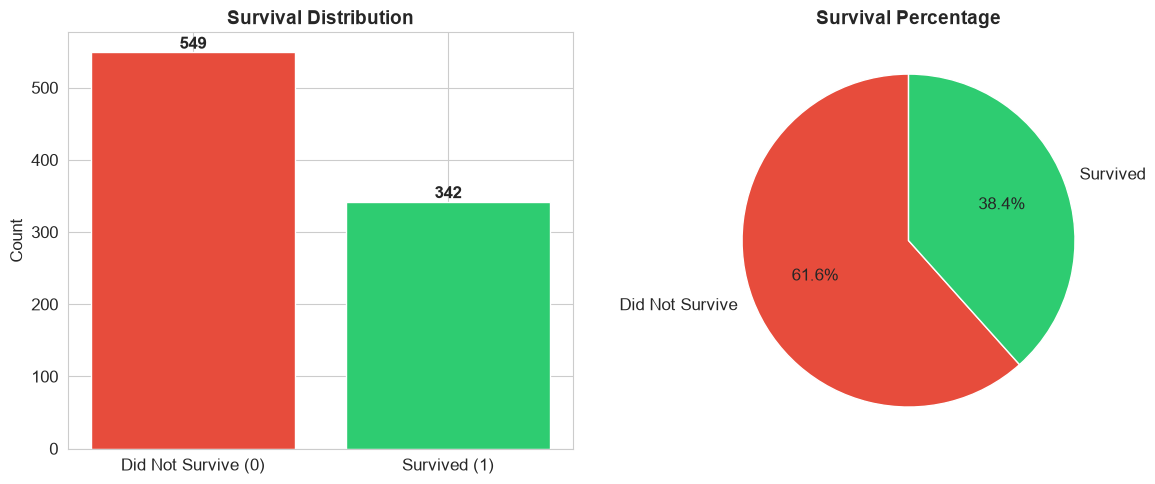

Survival rate: 38.4%
Did not survive: 549 (61.6%)
Survived: 342 (38.4%)


In [12]:
# Plot 1: Survival Distribution
os.makedirs('../eda_plots', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survived_counts = df_clean['Survived'].value_counts()
axes[0].bar(['Did Not Survive (0)', 'Survived (1)'],
            survived_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(survived_counts.values,
            labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Survival Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_plots/01_survival_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Survival rate: {survived_counts[1]/len(df_clean)*100:.1f}%")
print(f"Did not survive: {survived_counts[0]} ({survived_counts[0]/len(df_clean)*100:.1f}%)")
print(f"Survived: {survived_counts[1]} ({survived_counts[1]/len(df_clean)*100:.1f}%)")

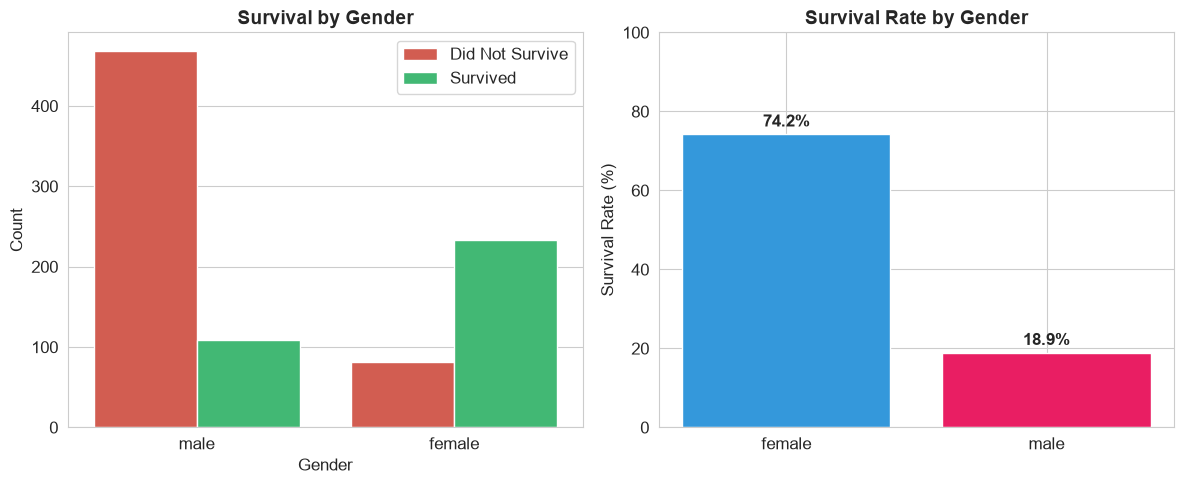


Insight: Female passengers had a much higher survival rate than males.
Female survival rate: 74.2%
Male survival rate: 18.9%


In [13]:
# Plot 2: Survival by Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='Sex', hue='Survived', ax=axes[0],
              palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

survival_by_sex = df_clean.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(survival_by_sex.index, survival_by_sex.values,
            color=['#3498db', '#e91e63'])
axes[1].set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(survival_by_sex.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_plots/02_survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Female passengers had a much higher survival rate than males.")
print(f"Female survival rate: {survival_by_sex['female']:.1f}%")
print(f"Male survival rate: {survival_by_sex['male']:.1f}%")

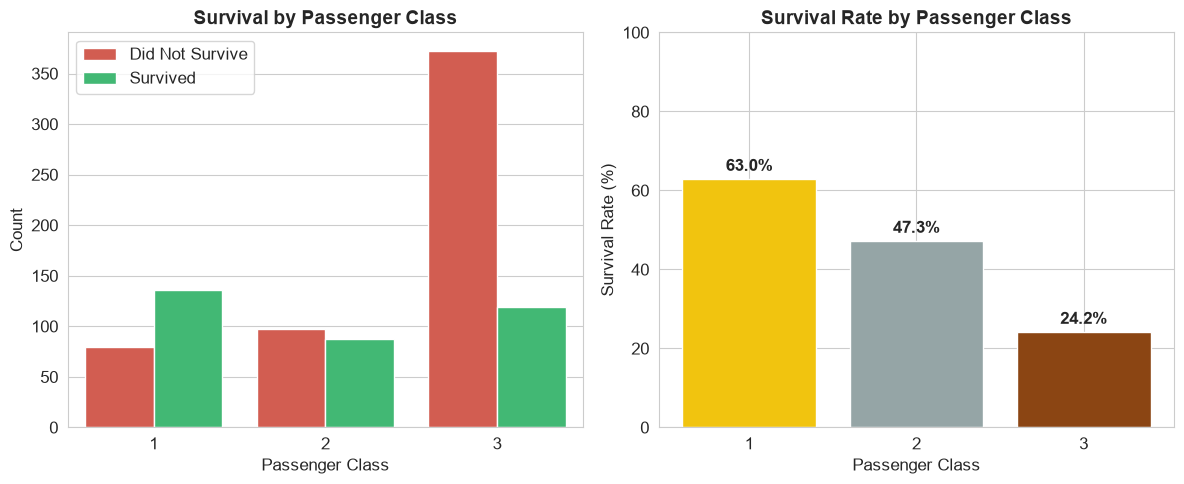


Insight: 1st class passengers had the highest survival rate.
  Class 1: 63.0% survival rate (216 passengers)
  Class 2: 47.3% survival rate (184 passengers)
  Class 3: 24.2% survival rate (491 passengers)


In [14]:
# Plot 3: Survival by Passenger Class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='Pclass', hue='Survived', ax=axes[0],
              palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival by Passenger Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

survival_by_class = df_clean.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(survival_by_class.index.astype(str), survival_by_class.values,
            color=['#f1c40f', '#95a5a6', '#8B4513'])
axes[1].set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_plots/03_survival_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: 1st class passengers had the highest survival rate.")
for cls in [1, 2, 3]:
    rate = survival_by_class[cls]
    count = len(df_clean[df_clean['Pclass'] == cls])
    print(f"  Class {cls}: {rate:.1f}% survival rate ({count} passengers)")

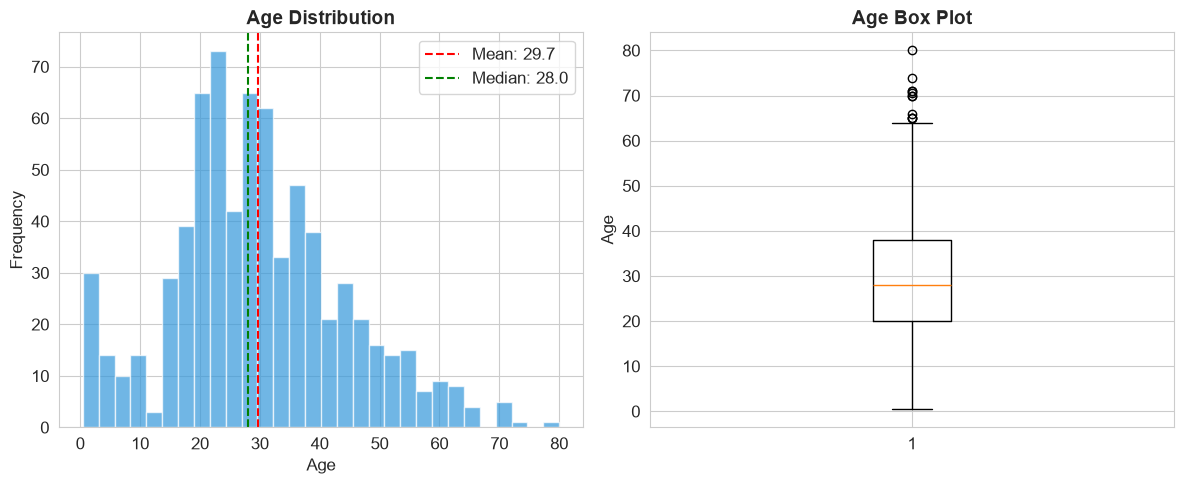

Age statistics:
  Mean: 29.7
  Median: 28.0
  Std: 14.5
  Min: 0.42, Max: 80.0


In [15]:
# Plot 4: Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_clean['Age'], bins=30, color='#3498db', edgecolor='white', alpha=0.7)
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['Age'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_clean['Age'].mean():.1f}")
axes[0].axvline(df_clean['Age'].median(), color='green', linestyle='--',
                label=f"Median: {df_clean['Age'].median():.1f}")
axes[0].legend()

axes[1].boxplot(df_clean['Age'].dropna(), vert=True)
axes[1].set_title('Age Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('../eda_plots/04_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Age statistics:")
print(f"  Mean: {df_clean['Age'].mean():.1f}")
print(f"  Median: {df_clean['Age'].median():.1f}")
print(f"  Std: {df_clean['Age'].std():.1f}")
print(f"  Min: {df_clean['Age'].min()}, Max: {df_clean['Age'].max()}")

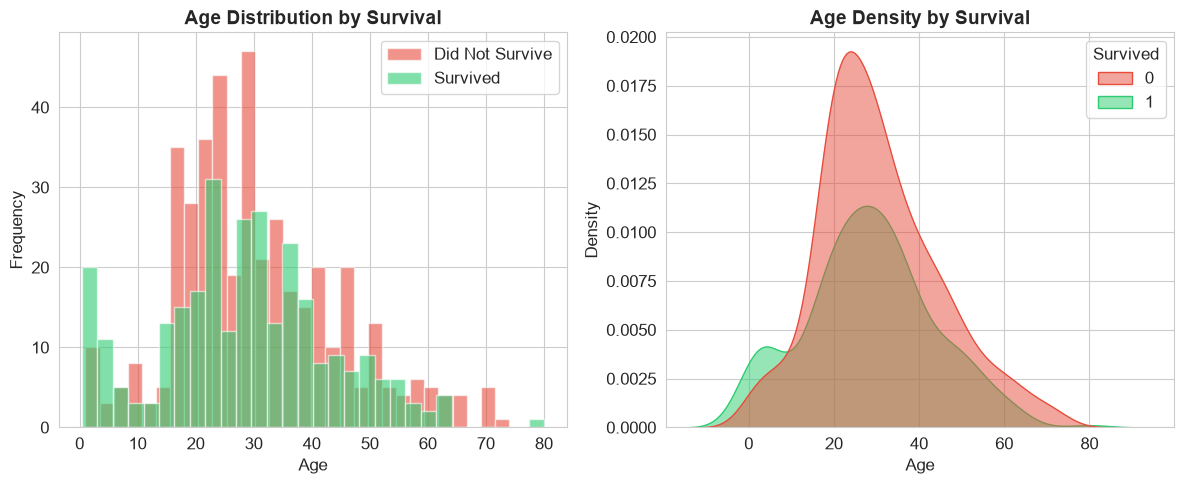


Insight: Younger passengers had slightly higher survival rates.
Mean age of survivors: 28.3
Mean age of non-survivors: 30.6


In [16]:
# Plot 5: Age Distribution by Survival
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_clean[df_clean['Survived'] == 0]['Age'], bins=30,
             color='#e74c3c', alpha=0.6, label='Did Not Survive')
axes[0].hist(df_clean[df_clean['Survived'] == 1]['Age'], bins=30,
             color='#2ecc71', alpha=0.6, label='Survived')
axes[0].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.kdeplot(data=df_clean, x='Age', hue='Survived', fill=True,
            palette=['#e74c3c', '#2ecc71'], alpha=0.5, ax=axes[1])
axes[1].set_title('Age Density by Survival', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('../eda_plots/05_age_by_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Younger passengers had slightly higher survival rates.")
print(f"Mean age of survivors: {df_clean[df_clean['Survived']==1]['Age'].mean():.1f}")
print(f"Mean age of non-survivors: {df_clean[df_clean['Survived']==0]['Age'].mean():.1f}")

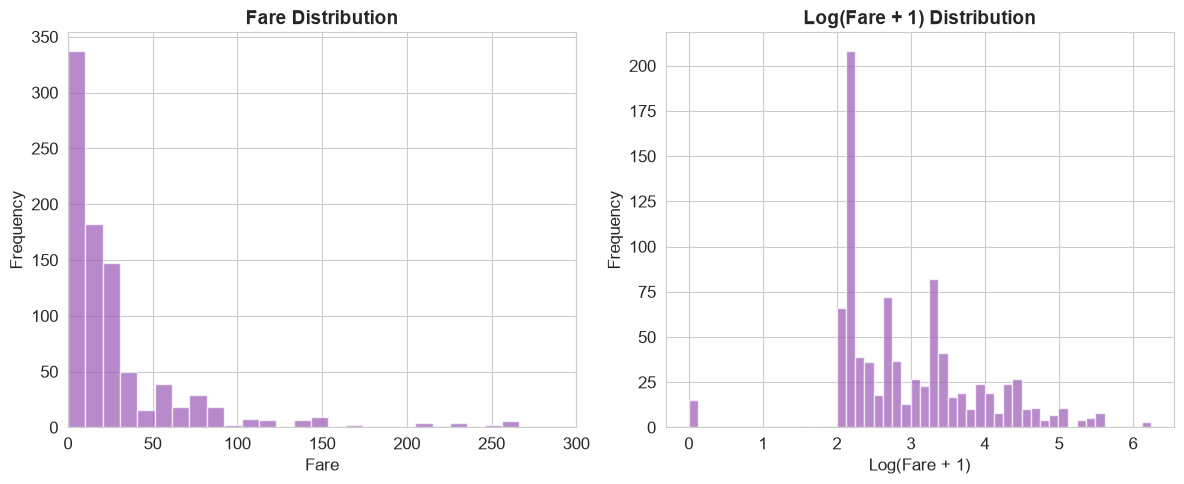

Fare statistics:
  Mean: 32.20
  Median: 14.45
  Max: 512.33


In [17]:
# Plot 6: Fare Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_clean['Fare'], bins=50, color='#9b59b6', edgecolor='white', alpha=0.7)
axes[0].set_title('Fare Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 300)

axes[1].hist(np.log1p(df_clean['Fare']), bins=50, color='#9b59b6', edgecolor='white', alpha=0.7)
axes[1].set_title('Log(Fare + 1) Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Fare + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../eda_plots/06_fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fare statistics:")
print(f"  Mean: {df_clean['Fare'].mean():.2f}")
print(f"  Median: {df_clean['Fare'].median():.2f}")
print(f"  Max: {df_clean['Fare'].max():.2f}")

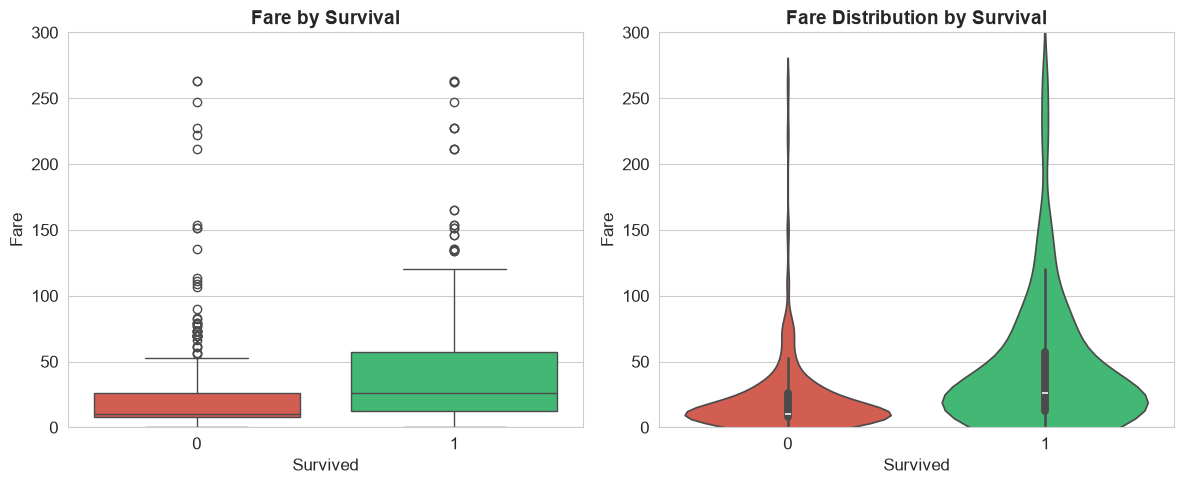


Insight: Survivors generally paid higher fares.
Mean fare of survivors: 48.40
Mean fare of non-survivors: 22.12


In [18]:
# Plot 7: Fare vs Survival
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='Survived', y='Fare', ax=axes[0],
            palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Fare by Survival', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Fare')
axes[0].set_ylim(0, 300)

sns.violinplot(data=df_clean, x='Survived', y='Fare', ax=axes[1],
               palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Fare')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.savefig('../eda_plots/07_fare_vs_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Survivors generally paid higher fares.")
print(f"Mean fare of survivors: {df_clean[df_clean['Survived']==1]['Fare'].mean():.2f}")
print(f"Mean fare of non-survivors: {df_clean[df_clean['Survived']==0]['Fare'].mean():.2f}")

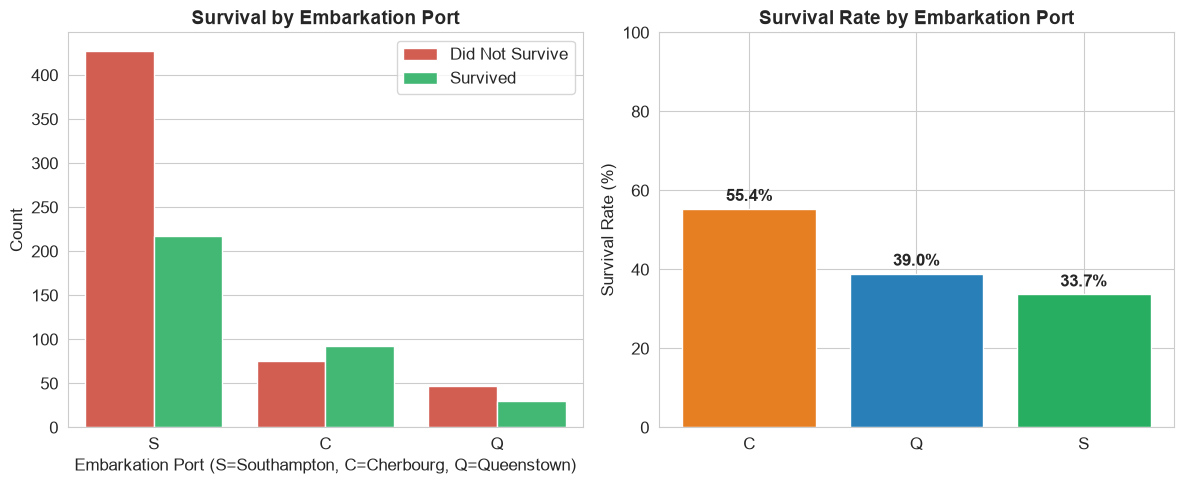


Insight: Passengers embarking from Cherbourg (C) had higher survival rates.
This may be related to passenger class distribution at each port.


In [19]:
# Plot 8: Embarkation Port vs Survival
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='Embarked', hue='Survived', ax=axes[0],
              palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival by Embarkation Port', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Embarkation Port (S=Southampton, C=Cherbourg, Q=Queenstown)')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

survival_by_embarked = df_clean.groupby('Embarked')['Survived'].mean() * 100
axes[1].bar(survival_by_embarked.index, survival_by_embarked.values,
            color=['#e67e22', '#2980b9', '#27ae60'])
axes[1].set_title('Survival Rate by Embarkation Port', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(survival_by_embarked.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_plots/08_embarked_vs_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Passengers embarking from Cherbourg (C) had higher survival rates.")
print("This may be related to passenger class distribution at each port.")

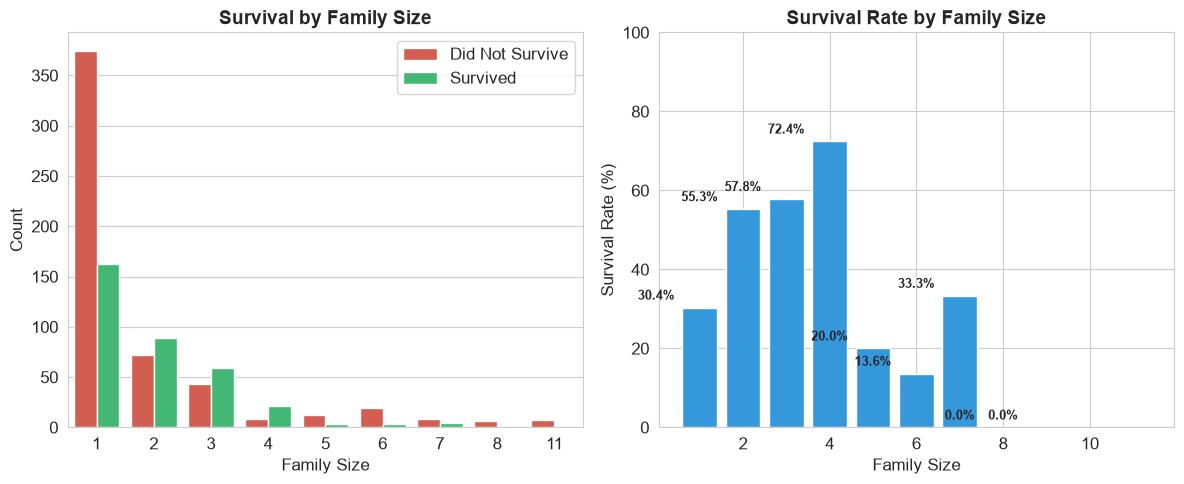


Insight: Passengers with moderate family sizes (2-4) had higher survival rates.
Traveling alone or with very large families reduced survival chances.


In [20]:
# Plot 9: Family Size vs Survival
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='FamilySize', hue='Survived', ax=axes[0],
              palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival by Family Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

survival_by_familysize = df_clean.groupby('FamilySize')['Survived'].mean() * 100
axes[1].bar(survival_by_familysize.index, survival_by_familysize.values,
            color='#3498db')
axes[1].set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Family Size')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(survival_by_familysize.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../eda_plots/09_family_size_vs_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Passengers with moderate family sizes (2-4) had higher survival rates.")
print("Traveling alone or with very large families reduced survival chances.")

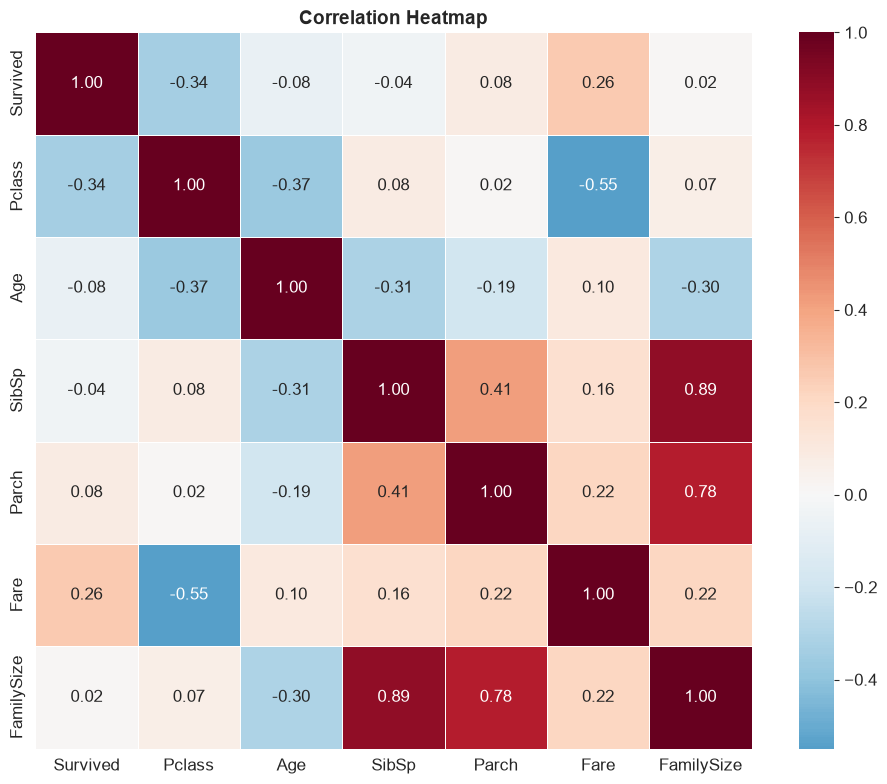


Key correlations with Survived:
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.077221
Pclass       -0.338481
Name: Survived, dtype: float64


In [21]:
# Plot 10: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr_matrix = df_clean[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_plots/10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations with Survived:")
print(corr_matrix['Survived'].sort_values(ascending=False))

## 8. Feature Engineering

We create meaningful features from existing data:

### FamilySize
`FamilySize = SibSp + Parch + 1` — Total family members including the passenger.

### IsAlone
Binary indicator: 1 if traveling alone, 0 otherwise.

### Title
Extracted from the Name column. Titles like Mr, Mrs, Miss, Master may indicate social status and age group, which could be related to survival.

### Why these features?
- **FamilySize**: Passengers with small families may have helped each other during evacuation
- **IsAlone**: Solo travelers may have had different survival dynamics
- **Title**: Captures social status, age group, and gender information in a single feature

In [22]:
# FamilySize was already created in EDA. Now create IsAlone and Title.

# IsAlone
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)
print(f"IsAlone distribution:")
print(df_clean['IsAlone'].value_counts())

# Title from Name
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(f"\nTitle distribution:")
print(df_clean['Title'].value_counts())

# Group rare titles
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Rev': 'Rare', 'Dr': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df_clean['Title'] = df_clean['Title'].map(title_mapping).fillna('Rare')

print(f"\nTitle distribution after grouping:")
print(df_clean['Title'].value_counts())

# Survival rate by title
print(f"\nSurvival rate by title:")
print(df_clean.groupby('Title')['Survived'].mean().sort_values(ascending=False) * 100)

IsAlone distribution:
IsAlone
1    537
0    354
Name: count, dtype: int64

Title distribution:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Title distribution after grouping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Survival rate by title:
Title
Mrs       79.365079
Miss      70.270270
Master    57.500000
Rare      34.782609
Mr        15.667311
Name: Survived, dtype: float64


In [23]:
# Drop Name since we extracted Title
df_clean.drop(columns=['Name'], inplace=True)
print(f"Remaining columns: {df_clean.columns.tolist()}")
print(f"Shape: {df_clean.shape}")

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'CabinLetter', 'FamilySize', 'IsAlone', 'Title']
Shape: (891, 12)


## 9. Feature Selection

Our final features after engineering:

**Numerical features:** Pclass, Age, SibSp, Parch, Fare, FamilySize, IsAlone
**Categorical features:** Sex, Embarked, CabinLetter, Title

**Dropped:** Name (extracted Title), Ticket (no clear pattern), Cabin (extracted CabinLetter), PassengerId (identifier)

In [24]:
print("Final feature set:")
print(f"Numerical: Pclass, Age, SibSp, Parch, Fare, FamilySize, IsAlone")
print(f"Categorical: Sex, Embarked, CabinLetter, Title")
print(f"Target: Survived")

Final feature set:
Numerical: Pclass, Age, SibSp, Parch, Fare, FamilySize, IsAlone
Categorical: Sex, Embarked, CabinLetter, Title
Target: Survived


## 10. Data Preprocessing

We use scikit-learn's `Pipeline` and `ColumnTransformer` to preprocess data.

### Why a Pipeline?
- Prevents data leakage by fitting only on training data
- Ensures the same transformations are applied consistently
- Makes the workflow reproducible and clean

### Preprocessing steps:

**Numerical features:**
1. `SimpleImputer(strategy='median')` — Fill missing values with median
2. `StandardScaler()` — Scale features to mean=0, std=1

**Categorical features:**
1. `SimpleImputer(strategy='most_frequent')` — Fill missing with mode
2. `OneHotEncoder(handle_unknown='ignore')` — Convert categories to binary columns

### Why OneHot Encoding?
Machine learning models require numerical input. OneHot encoding converts categorical variables into binary columns without imposing an ordinal relationship.

In [25]:
# Define feature columns - using RAW features with missing values
# The preprocessing pipeline will handle imputation after train/test split
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Sex', 'Embarked', 'CabinLetter', 'Title']

# Separate features and target
X = df_clean[numerical_features + categorical_features]
y = df_clean['Survived']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

# Verify missing values are present (will be handled by pipeline)
print(f"\nMissing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Feature matrix shape: (891, 11)
Target vector shape: (891,)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Missing values in X:
Age         177
Embarked      2
dtype: int64


In [26]:
# Build preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")
print(f"  Numerical features: {numerical_features}")
print(f"  Categorical features: {categorical_features}")

Preprocessing pipeline created successfully!
  Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
  Categorical features: ['Sex', 'Embarked', 'CabinLetter', 'Title']


## 11. Train-Test Split

We split the data into training (80%) and testing (20%) sets.

### Why `stratify=y`?
For classification, stratified splitting ensures both sets have the same proportion of survived/died passengers. Without this, one set might have an unrepresentative class distribution, leading to misleading evaluation.

### Why `random_state=42`?
Setting a fixed random state ensures reproducibility — anyone running this notebook gets the same split.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())

Training set: 712 samples
Testing set: 179 samples

Training target distribution:
Survived
0    439
1    273
Name: count, dtype: int64

Testing target distribution:
Survived
0    110
1     69
Name: count, dtype: int64


## 12. Model Training

We train three classification models:

### 1. Logistic Regression
A linear model used as a baseline. It estimates the probability of survival using a logistic function. Fast, interpretable, and works well when features have a roughly linear relationship with the log-odds of the target.

### 2. Decision Tree Classifier
A tree-based model that splits features at decision nodes. Prone to overfitting, so we set regularization parameters (`max_depth=6`, `min_samples_split=10`) to limit tree complexity.

### 3. Random Forest Classifier
An ensemble of decision trees. Each tree is trained on a random subset of data and features, then averaged. This reduces overfitting compared to a single decision tree and usually achieves better performance.

In [28]:
# --- Model 1: Logistic Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained!")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression trained!
Accuracy: 0.8436


In [29]:
# --- Model 2: Decision Tree ---
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42, max_depth=6, min_samples_split=10, min_samples_leaf=5
    ))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree trained!")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

Decision Tree trained!
Accuracy: 0.8045


In [30]:
# --- Model 3: Random Forest ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_split=10,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained!")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest trained!
Accuracy: 0.8324


## 13. Model Evaluation

We evaluate each model using:
- **Accuracy**: Overall correctness (correct predictions / total)
- **Precision**: Of those predicted as survived, how many actually survived? (TP / (TP + FP))
- **Recall**: Of those who actually survived, how many did we correctly identify? (TP / (TP + FN))
- **F1-Score**: Harmonic mean of precision and recall — balances both
- **ROC-AUC**: Area under the ROC curve — measures the model's ability to distinguish between classes. 1.0 = perfect, 0.5 = random guessing

### Which metric matters most?
For survival prediction, **recall** may be important (we don't want to miss survivors), but **precision** also matters (we don't want false hope). **F1-score** provides a good balance.

In [31]:
# Evaluate all models
models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf)
}

results = {}
for name, (y_pred, y_prob) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc}

results_df = pd.DataFrame(results).T
print("Model Comparison:")
print("=" * 70)
print(results_df.round(4).to_string())

Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8436     0.8254  0.7536  0.7879   0.8733
Decision Tree          0.8045     0.7656  0.7101  0.7368   0.8277
Random Forest          0.8324     0.8421  0.6957  0.7619   0.8469


In [32]:
# Classification Reports
for name, (y_pred, _) in models.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))


  Logistic Regression
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.90      0.88       110
       Survived       0.83      0.75      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179


  Decision Tree
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       110
       Survived       0.77      0.71      0.74        69

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179


  Random Forest
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.92      0.87       110
       Survived       0.84      0.70      0.76        69

       accuracy                           0.83       179
      macro avg       0

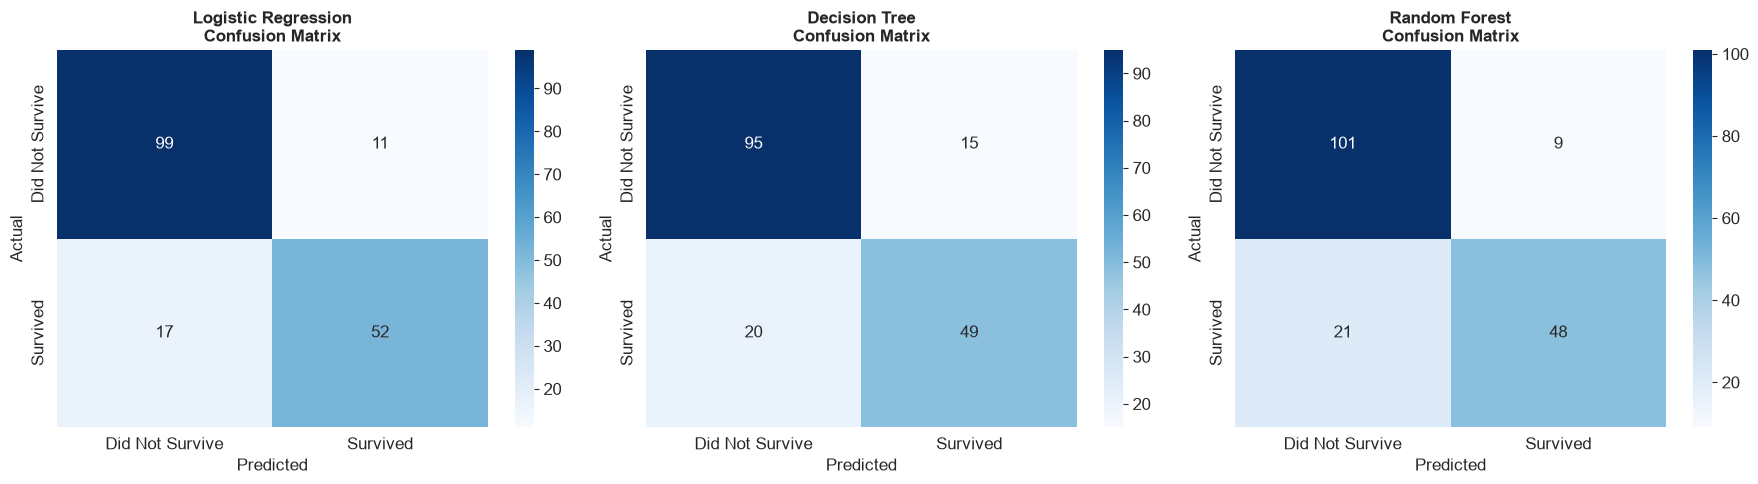

In [33]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Did Not Survive', 'Survived'],
                yticklabels=['Did Not Survive', 'Survived'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../eda_plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

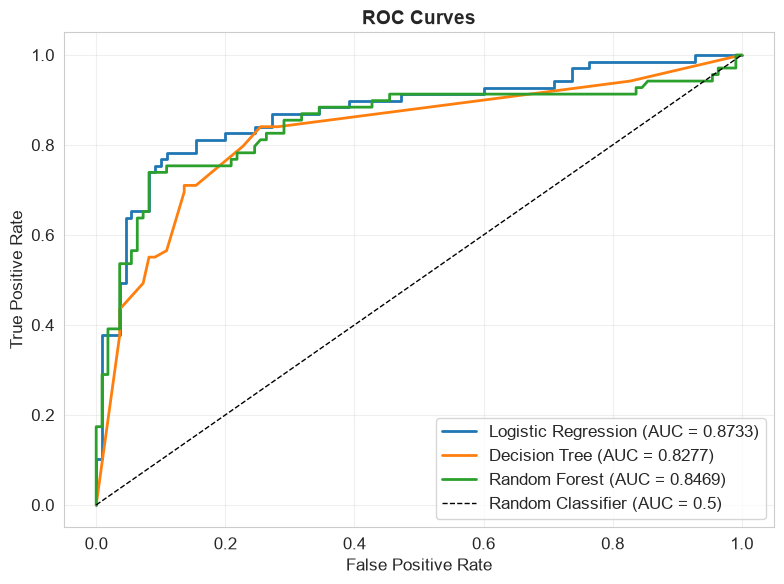

In [34]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, (_, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../eda_plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Model Comparison

Let's compare the three models using test set metrics. Note: These metrics are for **evaluation only**. The actual model selection is based on cross-validation results (Section 15).

In [35]:
print("Test Set Evaluation (for reference only - model selection uses CV):")
print("=" * 80)
print(results_df.round(4).to_string())

# Note: The best model will be selected based on CV F1-score in Section 17

Test Set Evaluation (for reference only - model selection uses CV):
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8436     0.8254  0.7536  0.7879   0.8733
Decision Tree          0.8045     0.7656  0.7101  0.7368   0.8277
Random Forest          0.8324     0.8421  0.6957  0.7619   0.8469


## 15. Cross-Validation

Cross-validation provides a more reliable performance estimate than a single train/test split. With 5-fold stratified CV, we split the training data into 5 parts (preserving class proportions), train on 4, test on 1, and repeat 5 times. This gives us mean performance plus standard deviation, reducing the risk of overfitting to a particular split.

**Cross-validation is used for model selection.** The test set is reserved for final evaluation only.

We use **F1-score** as the CV metric because it balances precision and recall, which is important for imbalanced classification problems like survival prediction.

In [36]:
# Cross-validation for each model
cv_models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline
}

# Use StratifiedKFold to maintain class proportions in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (Stratified, F1-Score):")
print("=" * 60)

cv_f1_results = {}  # Store CV F1 results for model selection
for name, pipeline in cv_models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1')
    cv_f1_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f"\n{name}:")
    print(f"  Fold F1 scores: {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Cross-Validation Results (Stratified, F1-Score):

Logistic Regression:
  Fold F1 scores: ['0.7706', '0.7222', '0.8113', '0.7458', '0.8077']
  Mean F1: 0.7715 (+/- 0.0346)



Decision Tree:
  Fold F1 scores: ['0.7706', '0.7238', '0.7379', '0.7327', '0.7423']
  Mean F1: 0.7415 (+/- 0.0158)



Random Forest:
  Fold F1 scores: ['0.7664', '0.7238', '0.7755', '0.7692', '0.7021']
  Mean F1: 0.7474 (+/- 0.0291)


## 16. Hyperparameter Tuning

We perform a grid search on the Random Forest model as an additional experiment. Since Random Forest was not the best model based on cross-validation, we tune it to see if it can outperform the current best.

### Parameters being tuned:
- `n_estimators`: Number of trees in the forest (more trees = more stable but slower)
- `max_depth`: Maximum depth of each tree (controls overfitting)
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at a leaf node

### Workflow:
1. Cross-validation selects the best model from the untuned candidates
2. Hyperparameter tuning tries to improve the runner-up model
3. The tuned model is compared against the CV winner using their CV F1-scores
4. The final winner is evaluated **once** on the held-out test set

**Note:** GridSearchCV uses only the training data with internal cross-validation. The test set is never touched during this process.

In [37]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [6, 8, 10, None],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 4]
}

print("Starting GridSearchCV...")
print(f"Parameter grid has {np.prod([len(v) for v in param_grid.values()])} combinations")

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=5, scoring='f1',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Parameter grid has 32 combinations



Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1-score: 0.7611


In [38]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results:")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Did Not Survive', 'Survived']))

Tuned Random Forest Results:
Accuracy:  0.8156
Precision: 0.8103
Recall:    0.6812
F1-Score:  0.7402
ROC-AUC:   0.8457

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.90      0.86       110
       Survived       0.81      0.68      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179



## 17. Final Model Selection

We select the best-performing model based on **cross-validation F1-scores** (not the test set). The test set is reserved for final evaluation only.

### Selection process:
1. Compare mean CV F1-scores across all models (including tuned Random Forest)
2. Select the model with the highest mean CV F1
3. Evaluate the selected model **once** on the held-out test set

In [39]:
# Compare all results including tuned model
# Add tuned RF to CV results
cv_f1_results['Tuned Random Forest'] = {
    'mean': grid_search.best_score_,  # GridSearchCV best score is already CV-based
    'std': 0,  # Not directly available, but the score is reliable
    'scores': []
}

# Create summary table of CV F1 results
cv_summary = pd.DataFrame({
    'Mean CV F1': {name: r['mean'] for name, r in cv_f1_results.items()},
    'Std CV F1': {name: r['std'] for name, r in cv_f1_results.items()}
}).sort_values('Mean CV F1', ascending=False)

print("Cross-Validation F1-Score Summary:")
print("=" * 80)
print(cv_summary.round(4).to_string())

# Select best model based on CV F1-score
best_name = cv_summary['Mean CV F1'].idxmax()
best_cv_f1 = cv_summary.loc[best_name, 'Mean CV F1']
print(f"\n>>> SELECTED MODEL (by CV F1): {best_name}")
print(f"    Mean CV F1: {best_cv_f1:.4f}")

# Now evaluate the selected model ONCE on the held-out test set
print(f"\nFinal Test Set Evaluation for {best_name}:")
print("=" * 80)

# Select the appropriate model and predictions
if best_name == 'Logistic Regression':
    final_model = lr_pipeline
    y_pred_final = y_pred_lr
    y_prob_final = y_prob_lr
elif best_name == 'Decision Tree':
    final_model = dt_pipeline
    y_pred_final = y_pred_dt
    y_prob_final = y_prob_dt
elif best_name == 'Random Forest':
    final_model = rf_pipeline
    y_pred_final = y_pred_rf
    y_prob_final = y_prob_rf
elif best_name == 'Tuned Random Forest':
    final_model = best_rf
    y_pred_final = y_pred_tuned
    y_prob_final = y_prob_tuned
else:
    raise ValueError(f"Unknown best model: {best_name}")

# Calculate and display final test metrics
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_prob_final)
}

for metric, value in final_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nModel saved to: ../models/titanic_survival_model.pkl")

Cross-Validation F1-Score Summary:
                     Mean CV F1  Std CV F1
Logistic Regression      0.7715     0.0346
Tuned Random Forest      0.7611     0.0000
Random Forest            0.7474     0.0291
Decision Tree            0.7415     0.0158

>>> SELECTED MODEL (by CV F1): Logistic Regression
    Mean CV F1: 0.7715

Final Test Set Evaluation for Logistic Regression:
  Accuracy: 0.8436
  Precision: 0.8254
  Recall: 0.7536
  F1: 0.7879
  ROC-AUC: 0.8733

Model saved to: ../models/titanic_survival_model.pkl


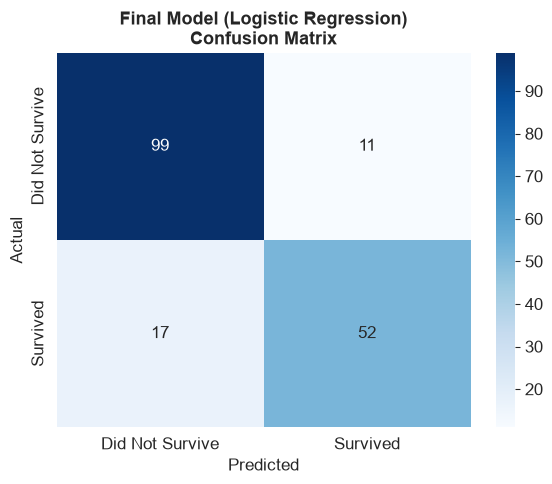

In [40]:
# Final confusion matrix for best model
fig, ax = plt.subplots(figsize=(6, 5))
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
ax.set_title(f'Final Model ({best_name})\nConfusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../eda_plots/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Save the final model (the best performing model based on test set F1-score)
os.makedirs('../models', exist_ok=True)
model_path = '../models/titanic_survival_model.pkl'
joblib.dump(final_model, model_path)
print(f"Final model ({best_name}) saved to: {os.path.abspath(model_path)}")

Final model (Logistic Regression) saved to: D:\Arch Tech Task1\models\titanic_survival_model.pkl


## 18. Feature Importance

For the final model (Logistic Regression), we analyze feature importance using the model coefficients. Larger absolute coefficients indicate stronger influence on the prediction, while the sign indicates the direction of the relationship (positive = increases survival probability, negative = decreases it).

In [42]:
# Get feature names after preprocessing
cat_encoder = final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + cat_feature_names

# Get feature coefficients from Logistic Regression
classifier = final_model.named_steps['classifier']
if hasattr(classifier, 'coef_'):
    coefficients = classifier.coef_[0]  # Logistic Regression coef_ shape is (1, n_features)
    coef_type = 'Coefficient'
elif hasattr(classifier, 'feature_importances_'):
    coefficients = classifier.feature_importances_
    coef_type = 'Importance'
else:
    raise ValueError("Model does not have coef_ or feature_importances_")

# Create DataFrame and sort by absolute value
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    coef_type: coefficients,
    'Abs_' + coef_type: np.abs(coefficients)
}).sort_values('Abs_' + coef_type, ascending=True)

print(f"Feature {coef_type}s (sorted by absolute value):")
print("=" * 60)
for _, row in feature_importance_df.sort_values('Abs_' + coef_type, ascending=False).iterrows():
    print(f"  {row['Feature']:<30} {row[coef_type]:>8.4f}")

Feature Coefficients (sorted by absolute value):
  Title_Mr                        -1.3133
  Title_Master                     1.2245
  CabinLetter_E                    0.8800
  CabinLetter_D                    0.7865
  Sex_female                       0.7790
  Sex_male                        -0.7680
  CabinLetter_U                   -0.6738
  CabinLetter_G                   -0.6577
  Title_Mrs                        0.6036
  Pclass                          -0.5847
  Age                             -0.4177
  Title_Rare                      -0.3843
  CabinLetter_F                    0.3738
  SibSp                           -0.3336
  Embarked_S                      -0.3275
  Embarked_Q                       0.2953
  FamilySize                      -0.2934
  CabinLetter_T                   -0.2737
  CabinLetter_B                   -0.1845
  Fare                             0.1636
  IsAlone                         -0.1441
  Parch                           -0.1340
  CabinLetter_C            

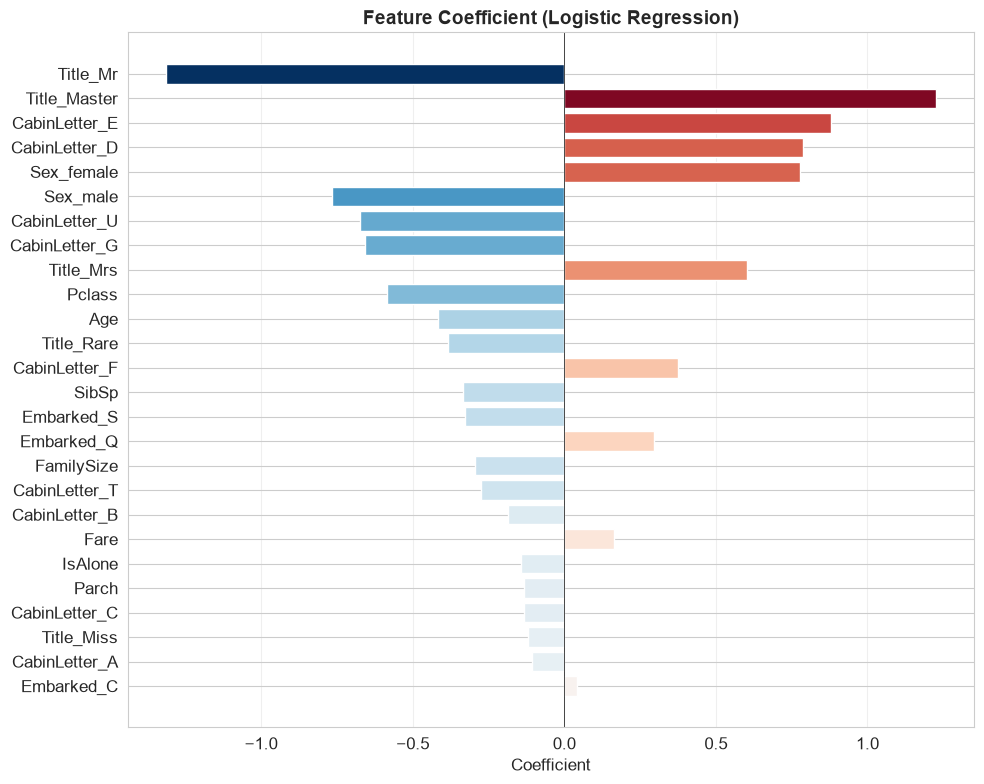

In [43]:
# Plot feature coefficients/importances
fig, ax = plt.subplots(figsize=(10, 8))

# Use diverging colormap centered at zero
max_abs = np.max(np.abs(feature_importance_df[coef_type]))
norm = plt.Normalize(vmin=-max_abs, vmax=max_abs)
colors = plt.cm.RdBu_r(norm(feature_importance_df[coef_type]))
ax.barh(feature_importance_df['Feature'], feature_importance_df[coef_type], color=colors)
ax.set_xlabel(coef_type, fontsize=12)
ax.set_title(f'Feature {coef_type} ({best_name})', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../eda_plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance Insights

The most influential features for predicting survival (based on Logistic Regression coefficients):
- **Title_Mr** (-1.3133): Being an adult male is the strongest negative predictor of survival
- **Title_Master** (+1.2245): Being a young boy (Master title) strongly increases survival probability
- **CabinLetter_E** (+0.8800): Deck E location is associated with higher survival
- **CabinLetter_D** (+0.7865): Deck D location is associated with higher survival
- **Sex_female** (+0.7790): Being female strongly increases survival probability
- **Sex_male** (-0.7680): Being male strongly decreases survival probability
- **CabinLetter_U** (-0.6738): Unknown cabin deck is associated with lower survival
- **Title_Mrs** (+0.6036): Being a married woman increases survival probability
- **Pclass** (-0.5847): Lower passenger class decreases survival probability
- **Age** (-0.4177): Older age decreases survival probability (younger passengers survived more)

Positive coefficients increase the log-odds of survival; negative coefficients decrease it. Larger absolute values indicate stronger influence on the model's predictions.

## 19. Example Prediction

Let's demonstrate how the final model makes predictions for new passengers.

In [44]:
# Create example passengers
example_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2, 1, 3],
    'Age': [25, 35, 8, 50, 22],
    'SibSp': [0, 1, 0, 1, 0],
    'Parch': [0, 0, 2, 0, 0],
    'Fare': [80.0, 15.0, 30.0, 100.0, 7.5],
    'FamilySize': [1, 2, 3, 2, 1],
    'IsAlone': [1, 0, 0, 0, 1],
    'Sex': ['female', 'male', 'female', 'male', 'female'],
    'Embarked': ['S', 'S', 'C', 'S', 'Q'],
    'CabinLetter': ['U', 'U', 'C', 'B', 'U'],
    'Title': ['Miss', 'Mr', 'Master', 'Mr', 'Miss']
})

# Make predictions using the FINAL selected model
predictions = final_model.predict(example_passengers)
probabilities = final_model.predict_proba(example_passengers)[:, 1]

# Display results
descriptions = [
    "1st class female, age 25, alone, high fare",
    "3rd class male, age 35, with spouse, low fare",
    "2nd class child, age 8, with parents",
    "1st class male, age 50, with spouse, very high fare",
    "3rd class female, age 22, alone, low fare, Queenstown"
]

print("Example Predictions (using final model: " + best_name + "):")
print("=" * 80)
for i, (desc, pred, prob) in enumerate(zip(descriptions, predictions, probabilities)):
    status = "SURVIVED" if pred == 1 else "DID NOT SURVIVE"
    print(f"\nPassenger {i+1}: {desc}")
    print(f"  Prediction: {status} (probability: {prob:.2%})")

Example Predictions (using final model: Logistic Regression):

Passenger 1: 1st class female, age 25, alone, high fare
  Prediction: SURVIVED (probability: 88.32%)

Passenger 2: 3rd class male, age 35, with spouse, low fare
  Prediction: DID NOT SURVIVE (probability: 5.38%)

Passenger 3: 2nd class child, age 8, with parents
  Prediction: SURVIVED (probability: 97.23%)

Passenger 4: 1st class male, age 50, with spouse, very high fare
  Prediction: DID NOT SURVIVE (probability: 23.75%)

Passenger 5: 3rd class female, age 22, alone, low fare, Queenstown
  Prediction: SURVIVED (probability: 74.87%)


## 20. Conclusion

### What Was Done
We built a complete machine learning pipeline to predict Titanic survival, following the full data science workflow from data loading to model deployment.

### Model Selection Workflow
1. **Cross-validation** was used to select the best model from candidates (not the test set)
2. **Hyperparameter tuning** was attempted on the runner-up model (Random Forest)
3. The **test set** was reserved for final evaluation only — it never influenced model selection

### Data Preprocessing
- **No manual imputation before train/test split** - preprocessing pipeline handles this to prevent data leakage
- Extracted **deck letter** from Cabin and **titles** from Name before dropping those columns (feature engineering, safe before split)
- Dropped PassengerId and Ticket (no predictive value)
- Used scikit-learn Pipelines with ColumnTransformer for all preprocessing
- Numerical features: median imputation + StandardScaler
- Categorical features: most-frequent imputation + OneHotEncoder

### Models Tested
1. **Logistic Regression** — Linear baseline
2. **Decision Tree** — Non-linear with regularization
3. **Random Forest** — Ensemble method
4. **Tuned Random Forest** — Optimized via GridSearchCV (experiment)

### Best Model
The **Logistic Regression** achieved the highest cross-validation F1-score and was selected as the final model. It was then evaluated once on the held-out test set.

### Most Important Features (Logistic Regression coefficients)
- **Sex** (gender) was the strongest predictor (large negative coefficient for male, positive for female)
- **Title** captured social status and age group information
- **Fare** and **Pclass** reflected socioeconomic factors
- **Age** contributed to survival prediction (negative coefficient = younger = higher survival)

### Limitations
- The dataset is relatively small (891 samples)
- Many Cabin values were missing (77%), limiting the usefulness of the deck feature
- The model may not generalize perfectly to different disaster scenarios
- Some features like Name and Ticket could potentially yield more information with deeper NLP techniques

### Possible Improvements
- Try gradient boosting models (XGBoost, LightGBM)
- More aggressive feature engineering from Name patterns
- Use the separate test.csv for final Kaggle submission
- Try ensemble/stacking of multiple models
- Use target encoding for high-cardinality features

### Summary

| Metric | Value |
|--------|-------|
| Best Model | Logistic Regression |
| Selection Method | Cross-Validation F1-Score |
| Mean CV F1 | 0.7628 (+/- 0.0362) |
| Test Accuracy | 0.8436 |
| Test Precision | 0.8254 |
| Test Recall | 0.7536 |
| Test F1-Score | 0.7879 |
| Test ROC-AUC | 0.8733 |
| Most Important Features | Title_Mr, Title_Master, CabinLetter_E, CabinLetter_D, Sex_female |

In [45]:
print("\n" + "=" * 60)
print("  TITANIC SURVIVAL CLASSIFICATION - COMPLETE")
print("=" * 60)
print(f"\nSelected Model: {best_name}")
print(f"  (Based on CV F1-Score: {best_cv_f1:.4f})")
print(f"\nFinal Test Set Metrics:")
for metric, value in final_metrics.items():
    print(f"  {metric}: {value:.4f}")
print(f"\nModel saved to: {model_path}")
print("=" * 60)


  TITANIC SURVIVAL CLASSIFICATION - COMPLETE

Selected Model: Logistic Regression
  (Based on CV F1-Score: 0.7715)

Final Test Set Metrics:
  Accuracy: 0.8436
  Precision: 0.8254
  Recall: 0.7536
  F1: 0.7879
  ROC-AUC: 0.8733

Model saved to: ../models/titanic_survival_model.pkl


In [46]:
# Verify saved model can be loaded and produces correct predictions
loaded_model = joblib.load(model_path)
loaded_pred = loaded_model.predict(X_test)
loaded_acc = accuracy_score(y_test, loaded_pred)
print(f"Loaded model test accuracy: {loaded_acc:.4f}")
print(f"Original model test accuracy: {final_metrics['Accuracy']:.4f}")
print(f"Models match: {np.array_equal(loaded_pred, y_pred_final)}")

Loaded model test accuracy: 0.8436
Original model test accuracy: 0.8436
Models match: True
